# Aprendizaje Automático - Clase 4
## Desarrollo Actividad 2 - Regresión Logística

Mediante las carácterístia de navegación que tiene el usuario, se debe predecir el Sistena Operativo que utiliza: Windows, Macintoch o Linux.

# Importamos las librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# Configuración para gráficos más nítidos
plt.rcParams["figure.figsize"] = (8, 5)
plt.style.use("ggplot")

# Cargamos el archivo CSV

In [2]:
# Carga del dataset

df = pd.read_csv("usuarios_win_mac_lin.csv")

# Inspección del dataset

In [3]:
print("Visualización de las primeras filas:")
display(df.head())
print("\nCantidad de filas y columnas:", df.shape)
print("\nInformación general:")
print(df.info())
print("\nDescripción estadística:")
df.describe()

Visualización de las primeras filas:


,duracion,paginas,acciones,valor,clase
0,7.0,2,4,8,2
1,21.0,2,6,6,2
2,57.0,2,4,4,2
3,101.0,3,6,12,2
4,109.0,2,6,12,2



Cantidad de filas y columnas: (170, 5)

Información general:
<class 'pandas.DataFrame'>
RangeIndex: 170 entries, 0 to 169
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   duracion  170 non-null    float64
 1   paginas   170 non-null    int64  
 2   acciones  170 non-null    int64  
 3   valor     170 non-null    int64  
 4   clase     170 non-null    int64  
dtypes: float64(1), int64(4)
memory usage: 6.8 KB
None

Descripción estadística:


,duracion,paginas,acciones,valor,clase
count,170.000000,170.000000,170.000000,170.000000,170.000000
mean,111.075729,2.041176,8.723529,32.676471,0.752941
std,202.453200,1.500911,9.136054,44.751993,0.841327
min,1.000000,1.000000,1.000000,1.000000,0.000000
25%,11.000000,1.000000,3.000000,8.000000,0.000000
50%,13.000000,2.000000,6.000000,20.000000,0.000000
75%,108.000000,2.000000,10.000000,36.000000,2.000000
max,898.000000,9.000000,63.000000,378.000000,2.000000


# Detectar valores faltantes

In [4]:
print("\nCantidad de valores faltantes por columna:")
print(df.isna().sum())


Cantidad de valores faltantes por columna:
duracion    0
paginas     0
acciones    0
valor       0
clase       0
dtype: int64


# Detectar duplicados y eliminarlos

In [5]:
print("Cantidad de filas duplicadas:", df.duplicated().sum())
# Muestra todas las filas que están repetidas (por defecto mantiene la primera aparición oculta)
filas_duplicadas = df[df.duplicated()]
print(filas_duplicadas)

Cantidad de filas duplicadas: 16
     duracion  paginas  acciones  valor  clase
106      12.0        1         6     24      1
108      12.0        1         6     24      1
113      12.0        1         2      2      2
115      12.0        1         3      6      2
118      12.0        1         3      3      2
120      11.0        1         3      6      2
121      12.0        1         3      6      2
122      12.0        1         2      2      2
123      12.0        1         3      3      2
124      11.0        1         3      3      2
125      11.0        1         2      4      2
127      11.0        1         3      3      2
128      12.0        1         1      1      2
149      11.0        1         2      6      0
157      11.0        1         5     15      0
158      12.0        1         8     24      0


In [6]:
df.drop_duplicates(inplace=True)
print("Cantidad de filas duplicadas después de la eliminación:", df.duplicated().sum())
print("Nueva cantidad de filas y columnas:", df.shape)

Cantidad de filas duplicadas después de la eliminación: 0
Nueva cantidad de filas y columnas: (154, 5)


# Distribución de la variable de estudio ´clase´

In [7]:
print("\nDistribución de la variable clase (0 – Windows, 1 – Macintosh, 2 -Linux):")
print(df["clase"].value_counts())


Distribución de la variable clase (0 – Windows, 1 – Macintosh, 2 -Linux):
clase
0    83
1    38
2    33
Name: count, dtype: int64


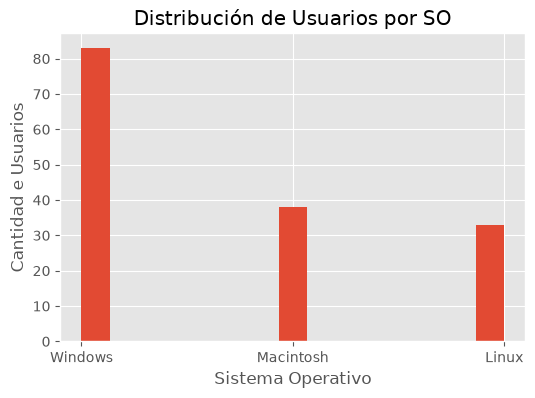

In [8]:
# Histograma de la variable clase
plt.figure(figsize=(6,4))
df['clase'].hist(bins=15)
plt.title("Distribución de Usuarios por SO")
plt.xlabel("Sistema Operativo")
plt.ylabel("Cantidad e Usuarios")
plt.xticks([0, 1, 2], ['Windows', 'Macintosh', 'Linux'])
plt.show()

# Histogramas y Boxplots para observar la distribución y detectar posibles outliers.

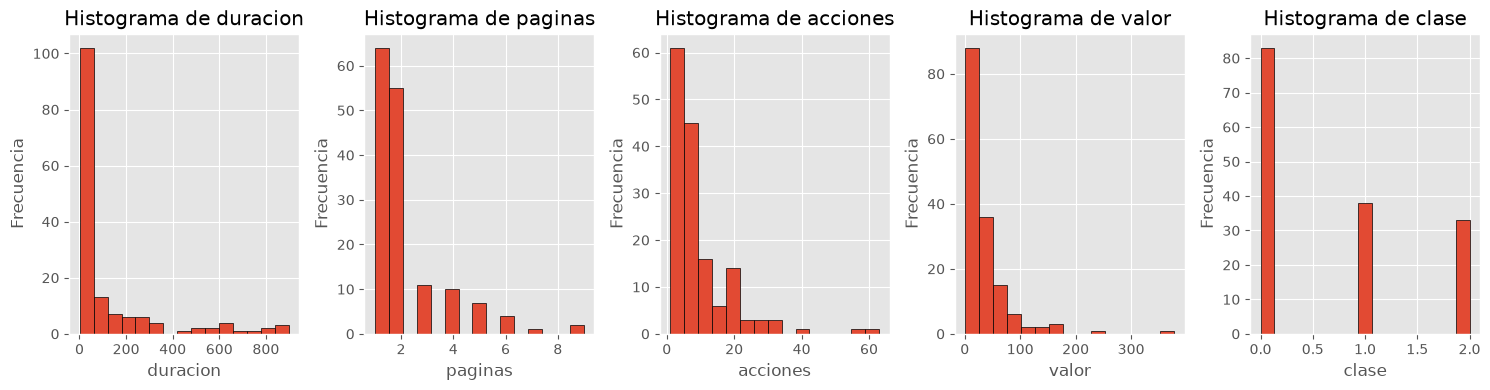

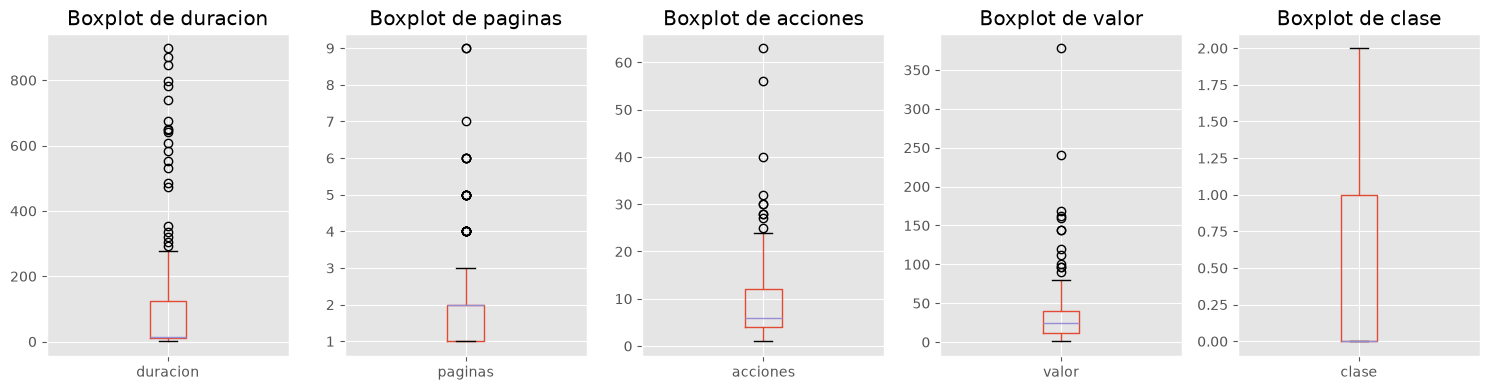

In [9]:
# Seleccionamos solo columnas numéricas
numericas = ["duracion", "paginas", "acciones", "valor", "clase"]

# Histogramas
fig, axes = plt.subplots(1, 5, figsize=(15, 4))

for ax, columna in zip(axes, numericas):
    df[columna].hist(bins=15, ax=ax, edgecolor="black")
    ax.set_title(f"Histograma de {columna}")
    ax.set_xlabel(columna)
    ax.set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()

# Boxplots
fig, axes = plt.subplots(1, 5, figsize=(15, 4))

for ax, columna in zip(axes, numericas):
    df.boxplot(column=columna, ax=ax)
    ax.set_title(f"Boxplot de {columna}")

plt.tight_layout()
plt.show()

# Relaciones entre variables

In [10]:
print("Matriz de correlación")
corr = df[numericas].corr()
df.corr()

Matriz de correlación


,duracion,paginas,acciones,valor,clase
duracion,1.000000,0.251451,0.137718,0.064767,0.193266
paginas,0.251451,1.000000,0.713880,0.568397,0.012992
acciones,0.137718,0.713880,1.000000,0.858074,-0.296065
valor,0.064767,0.568397,0.858074,1.000000,-0.290570
clase,0.193266,0.012992,-0.296065,-0.290570,1.000000


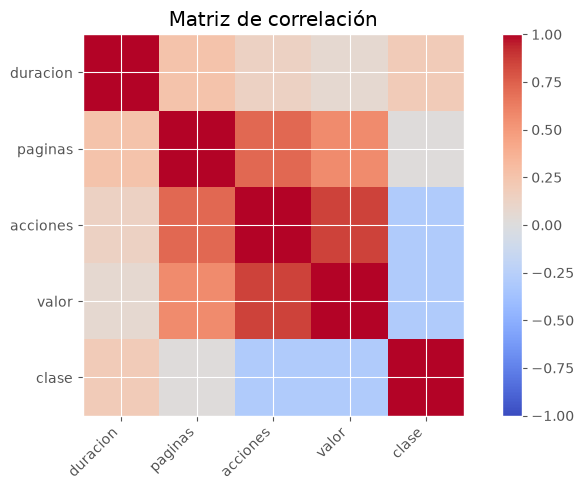

In [11]:
plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.xticks(range(len(corr)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr)), corr.columns)
plt.colorbar()
plt.title("Matriz de correlación")
plt.tight_layout()
plt.show()

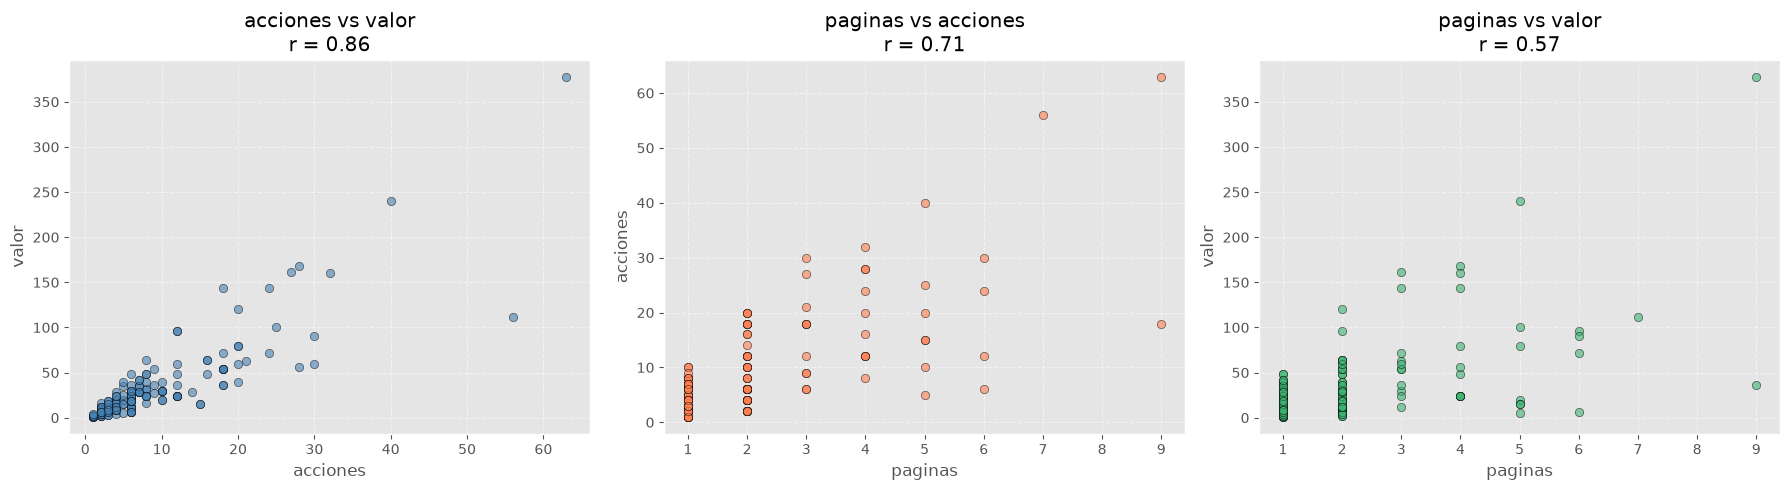

In [12]:
# Scatterplots Principales

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

pares = [
    ('acciones', 'valor', 'steelblue'),
    ('paginas', 'acciones', 'coral'),
    ('paginas', 'valor', 'mediumseagreen')
]

for ax, (x, y, color) in zip(axes, pares):
    ax.scatter(df[x], df[y], alpha=0.6, color=color, edgecolor='k')
    r = corr.loc[x, y]
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.set_title(f'{x} vs {y}\nr = {r:.2f}')
    ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Modelo de Regresión Logística Multinomial

In [13]:
# Separamos las variables predictoras (X_clase) y la variable objetivo (y_clase)
X_clase = df.drop("clase", axis=1)
y_clase = df["clase"]

# Dividimos el dataset en datos de entrenamiento (70%) y de prueba (30%)
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clase, y_clase, test_size=0.3, random_state=42)

print("Tamaños de los dataset:")
print("   Entrenamiento:", X_train_c.shape)
print("   Prueba:", X_test_c.shape)

Tamaños de los dataset:
   Entrenamiento: (107, 4)
   Prueba: (47, 4)


### Aplicación de RobustScaler

Vamos a escalar las variables predictoras para mejorar el rendimiento del modelo, especialmente porque hay valores extremos que son propio del dataset.

In [14]:
from sklearn.preprocessing import RobustScaler

# Inicializar RobustScaler
scaler = RobustScaler()

# Ajustar el escalador solo con los datos de entrenamiento y luego transformarlos
X_train_c_scaled = scaler.fit_transform(X_train_c)
X_test_c_scaled = scaler.transform(X_test_c)

print("Datos de entrenamiento escalados:")
print(X_train_c_scaled[:5])
print("\nDatos de prueba escalados:")
print(X_test_c_scaled[:5])

Datos de entrenamiento escalados:
[[ 0.18090452  0.          0.          0.33333333]
 [ 0.96482412  0.          0.         -0.26666667]
 [ 4.74371859  0.          0.          0.33333333]
 [-0.06030151 -1.          0.14285714  0.26666667]
 [-0.01005025 -1.         -0.42857143 -0.46666667]]

Datos de prueba escalados:
[[-0.11954774  0.         -0.28571429 -0.4       ]
 [-0.0201005  -1.          0.          0.13333333]
 [ 0.         -1.          0.14285714  0.26666667]
 [ 0.         -1.         -0.42857143 -0.06666667]
 [-0.01005025 -1.         -0.42857143 -0.56666667]]


### Modelo de Regresión Logística con datos escalados

In [15]:
# Modelo de Regresión Logística Multinomial con datos escalados
#log_reg_scaled = LogisticRegression(max_iter=1000, multi_class="multinomial", solver="lbfgs", class_weight='balanced')
log_reg_scaled = LogisticRegression(max_iter=1000, solver="lbfgs", class_weight='balanced')
log_reg_scaled.fit(X_train_c_scaled, y_train_c)

# Predicciones con datos de prueba escalados
y_pred_clase_scaled = log_reg_scaled.predict(X_test_c_scaled)

print("Modelo de Regresión Logística Multinomial (con datos escalados).....OK\n")

Modelo de Regresión Logística Multinomial (con datos escalados).....OK



### Evaluación del Modelo con datos escalados

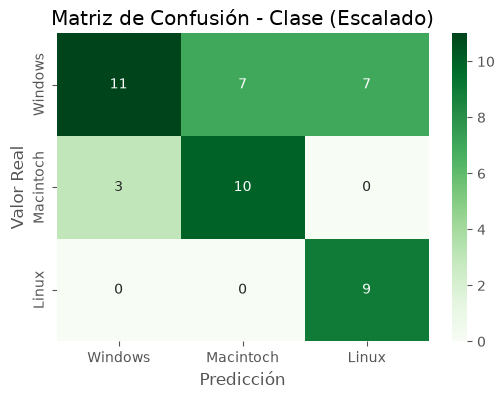

In [16]:
# Matriz de Confusión con datos escalados
cm_clase_scaled = confusion_matrix(y_test_c, y_pred_clase_scaled)
plt.figure(figsize=(6,4))
sns.heatmap(cm_clase_scaled, annot=True, fmt="d", cmap="Greens",
            xticklabels=["Windows","Macintoch","Linux"],
            yticklabels=["Windows","Macintoch","Linux"])
plt.title("Matriz de Confusión - Clase (Escalado)")
plt.xlabel("Predicción")
plt.ylabel("Valor Real")
plt.show()

In [17]:
# Reporte de métricas con datos escalados
acc_scaled = log_reg_scaled.score(X_test_c_scaled, y_test_c)
print(f"Accuracy del conjunto de prueba (escalado): {acc_scaled:.2f}")

print("\nReporte de Clasificación (escalado):")
print(classification_report(y_test_c, y_pred_clase_scaled, target_names=["Windows","Macintoch","Linux"]))

Accuracy del conjunto de prueba (escalado): 0.64

Reporte de Clasificación (escalado):
              precision    recall  f1-score   support

     Windows       0.79      0.44      0.56        25
   Macintoch       0.59      0.77      0.67        13
       Linux       0.56      1.00      0.72         9

    accuracy                           0.64        47
   macro avg       0.65      0.74      0.65        47
weighted avg       0.69      0.64      0.62        47



# **Conclusión**

Aplicamos Regresión Logística Multiclase para predecir el sistema operativo de los usuarios (Windows, Macintosh y Linux). Utilizando las cuatro característica de navegación web que treae el dataset.

Considerando  que las variables presentan valores extremos válidos (outliers), usamos RobustScaler() antes de aplicar el modelo.

En la función de LogisticRegression usamos el parámetro class_weight = 'balanced', para evittar el sesgo hacia la clase mayoritaria (Windows).

El modelo alcanzó una accuracy del 64%, es decir que clasifica de manera correcta el sistema operativo de 6 de cada 10 usuarios en dataset de prueba.